# House Prices Prediction

## Wojciech Ossowski ##

## Import the library

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Comment this if the data visualisations doesn't work on your side
%matplotlib inline

## Load the dataset


In [13]:

train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

train_df["dataset"] = "train"
test_df["dataset"] = "test"

dataset_df = pd.concat([train_df, test_df], axis=0, ignore_index=True, sort=False)
print("Full dataset shape is {}".format(dataset_df.shape))

Full dataset shape is (2919, 82)


The data is composed of 81 columns and 1460 entries. We can see all 81 dimensions of our dataset by printing out the first 3 entries using the following code:

In [14]:
dataset_df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,dataset
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0,train
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0,train
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0,train


* There are 79 feature columns. Using these features your model has to predict the house sale price indicated by the label column named `SalePrice`.

We will drop the `Id` column as it is not necessary for model training.

In [15]:
dataset_df = dataset_df.drop('Id', axis=1)
dataset_df.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,dataset
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0,train
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0,train
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0,train


We can inspect the types of feature columns using the following code:

In [16]:
dataset_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2919 non-null   int64  
 1   MSZoning       2915 non-null   str    
 2   LotFrontage    2433 non-null   float64
 3   LotArea        2919 non-null   int64  
 4   Street         2919 non-null   str    
 5   Alley          198 non-null    str    
 6   LotShape       2919 non-null   str    
 7   LandContour    2919 non-null   str    
 8   Utilities      2917 non-null   str    
 9   LotConfig      2919 non-null   str    
 10  LandSlope      2919 non-null   str    
 11  Neighborhood   2919 non-null   str    
 12  Condition1     2919 non-null   str    
 13  Condition2     2919 non-null   str    
 14  BldgType       2919 non-null   str    
 15  HouseStyle     2919 non-null   str    
 16  OverallQual    2919 non-null   int64  
 17  OverallCond    2919 non-null   int64  
 18  YearBuilt      2919

## House Price Distribution

Now let us take a look at how the house prices are distributed.

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


C:\Users\kakka\AppData\Local\Temp\ipykernel_74208\3430012634.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset_df['SalePrice'], color='g', bins=100, hist_kws={'alpha': 0.4});


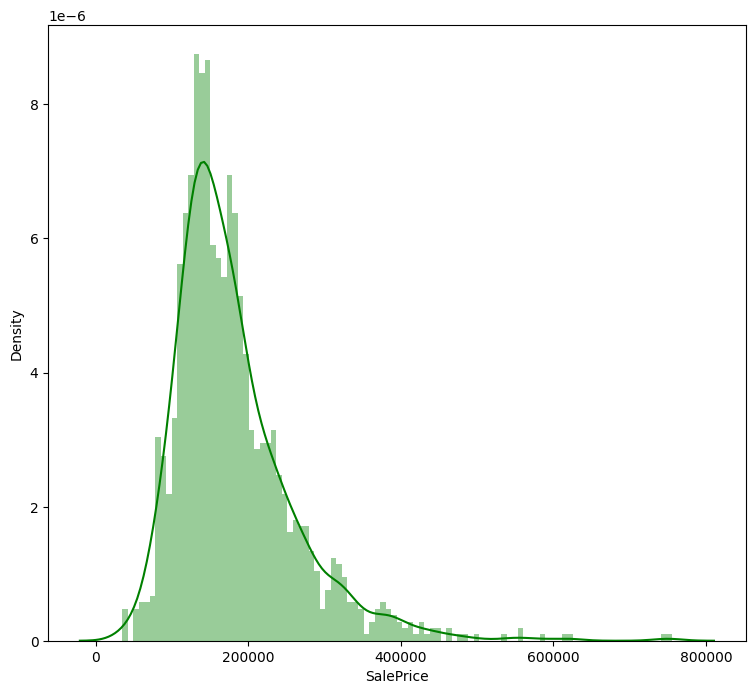

In [17]:
print(dataset_df['SalePrice'].describe())
plt.figure(figsize=(9, 8))
sns.distplot(dataset_df['SalePrice'], color='g', bins=100, hist_kws={'alpha': 0.4});

## Numerical data distribution

We will now take a look at how the numerical features are distributed. In order to do this, let us first list all the types of data from our dataset and select only the numerical ones.

In [18]:
list(set(dataset_df.dtypes.tolist()))

[dtype('float64'),
 dtype('int64'),
 <StringDtype(storage='python', na_value=nan)>]

In [19]:
df_num = dataset_df.select_dtypes(include = ['float64', 'int64'])
df_num.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706.0,0.0,...,0,61,0,0,0,0,0,2,2008,208500.0
1,20,80.0,9600,6,8,1976,1976,0.0,978.0,0.0,...,298,0,0,0,0,0,0,5,2007,181500.0
2,60,68.0,11250,7,5,2001,2002,162.0,486.0,0.0,...,0,42,0,0,0,0,0,9,2008,223500.0
3,70,60.0,9550,7,5,1915,1970,0.0,216.0,0.0,...,0,35,272,0,0,0,0,2,2006,140000.0
4,60,84.0,14260,8,5,2000,2000,350.0,655.0,0.0,...,192,84,0,0,0,0,0,12,2008,250000.0


Now let us plot the distribution for all the numerical features.

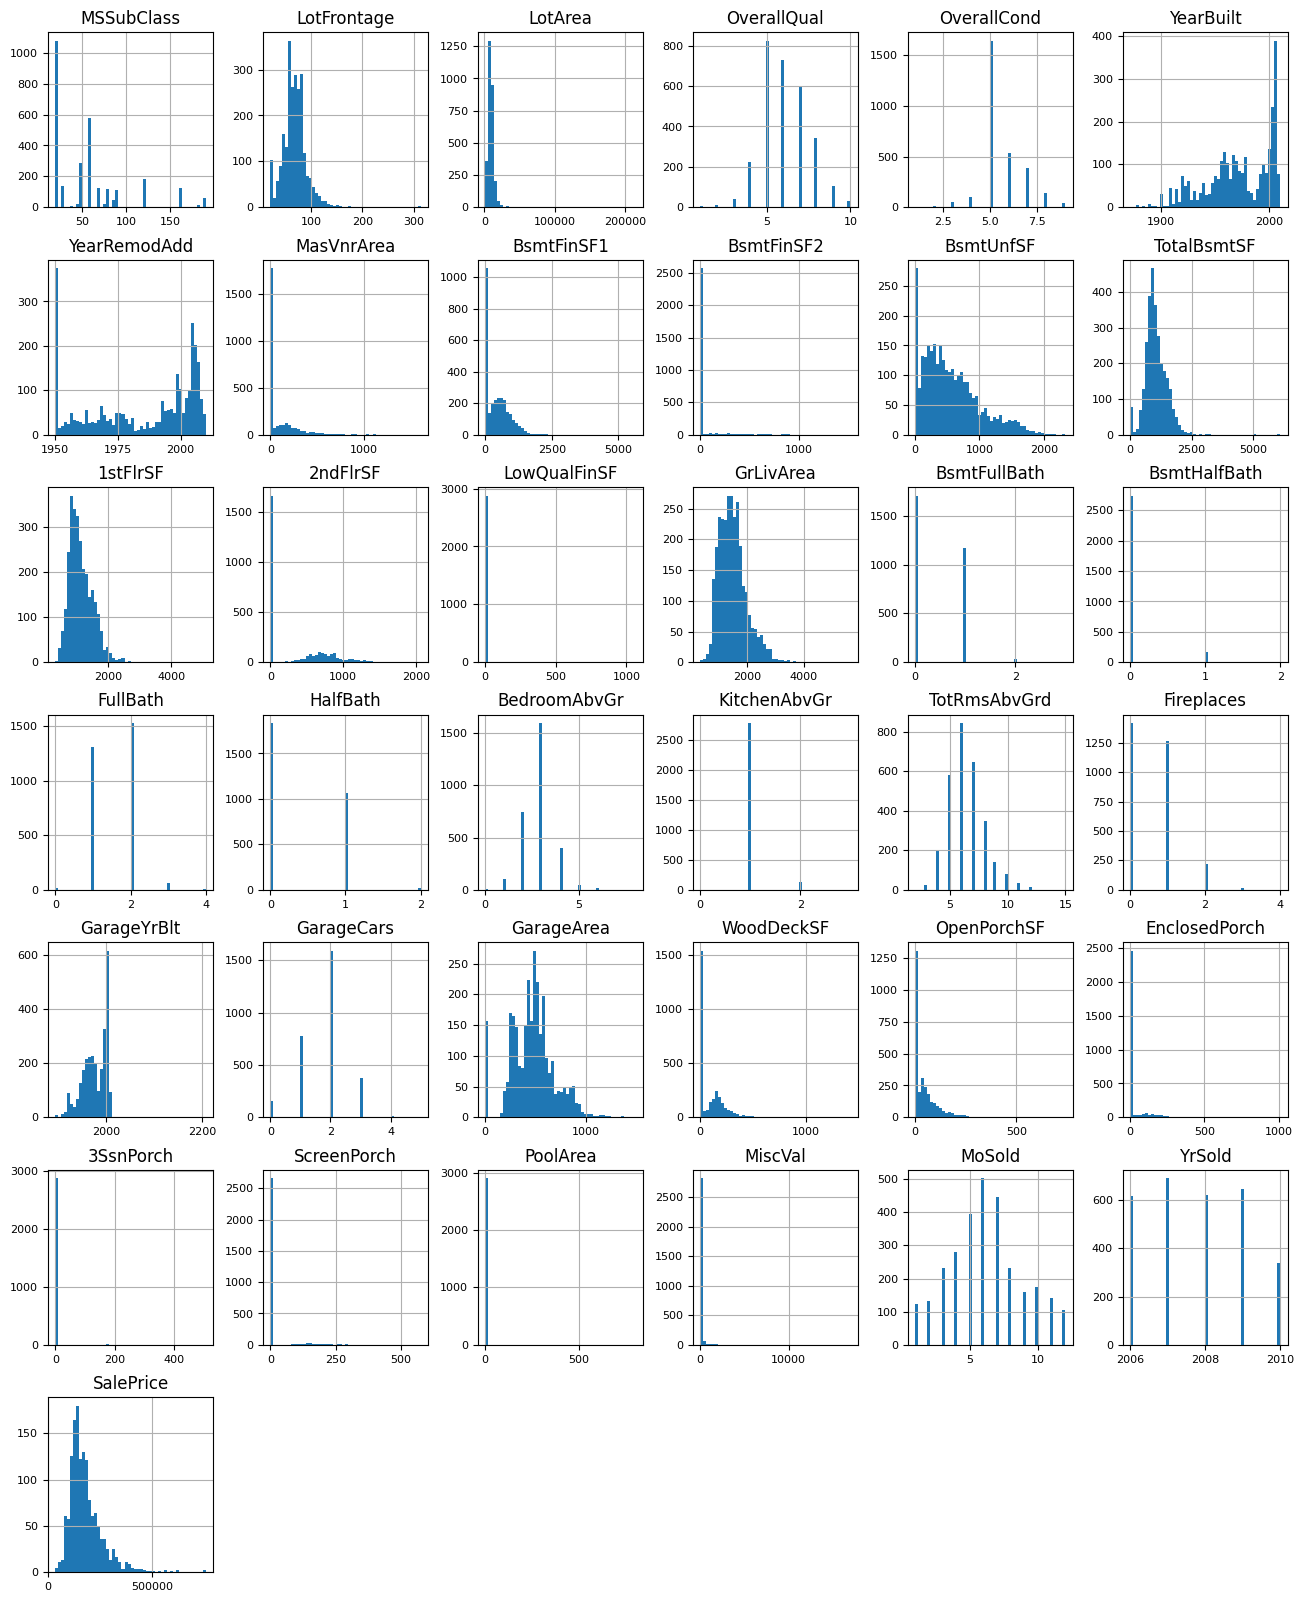

In [20]:
df_num.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

## Missing values in the training set

In [23]:
missing_values = dataset_df.isna().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]
missing_df = pd.DataFrame({
    "missing_count": missing_values,
    "missing_pct": 100 * missing_values / len(dataset_df)
})
missing_df.style.format({"missing_pct": "{:.2f}%"})

,missing_count,missing_pct
PoolQC,2909,99.66%
MiscFeature,2814,96.40%
Alley,2721,93.22%
Fence,2348,80.44%
MasVnrType,1766,60.50%
SalePrice,1459,49.98%
FireplaceQu,1420,48.65%
LotFrontage,486,16.65%
GarageCond,159,5.45%
GarageFinish,159,5.45%


### Missing values visualization

<Figure size 1200x600 with 0 Axes>

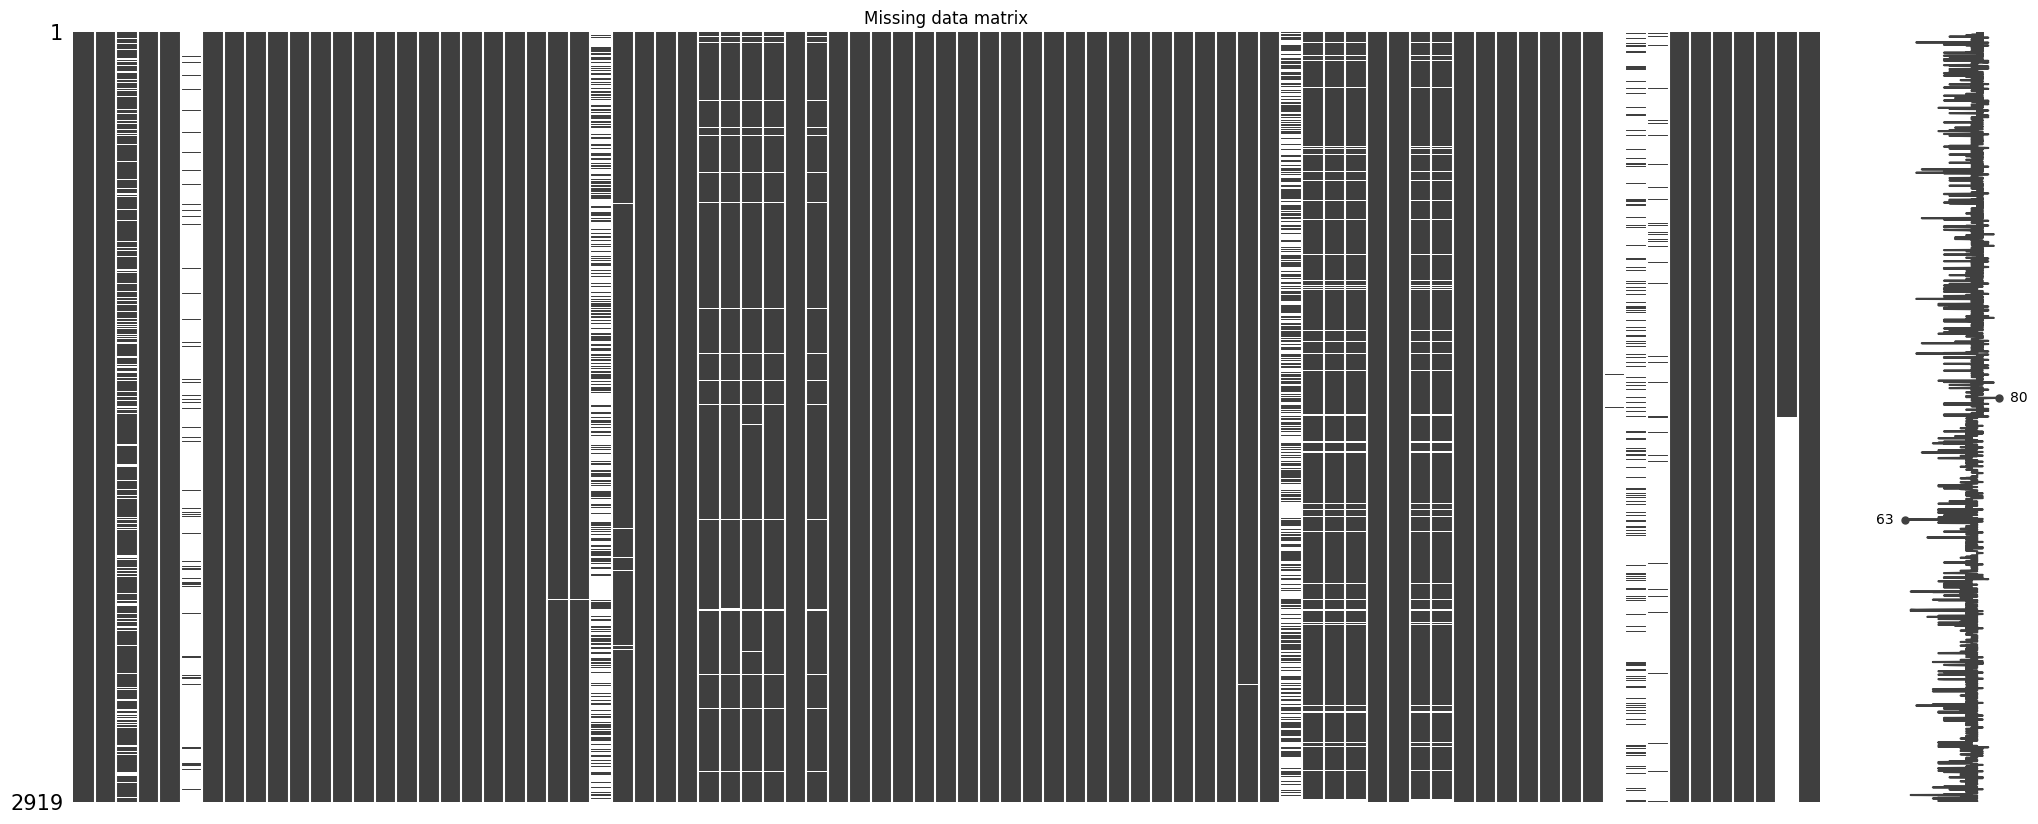

<Figure size 1200x600 with 0 Axes>

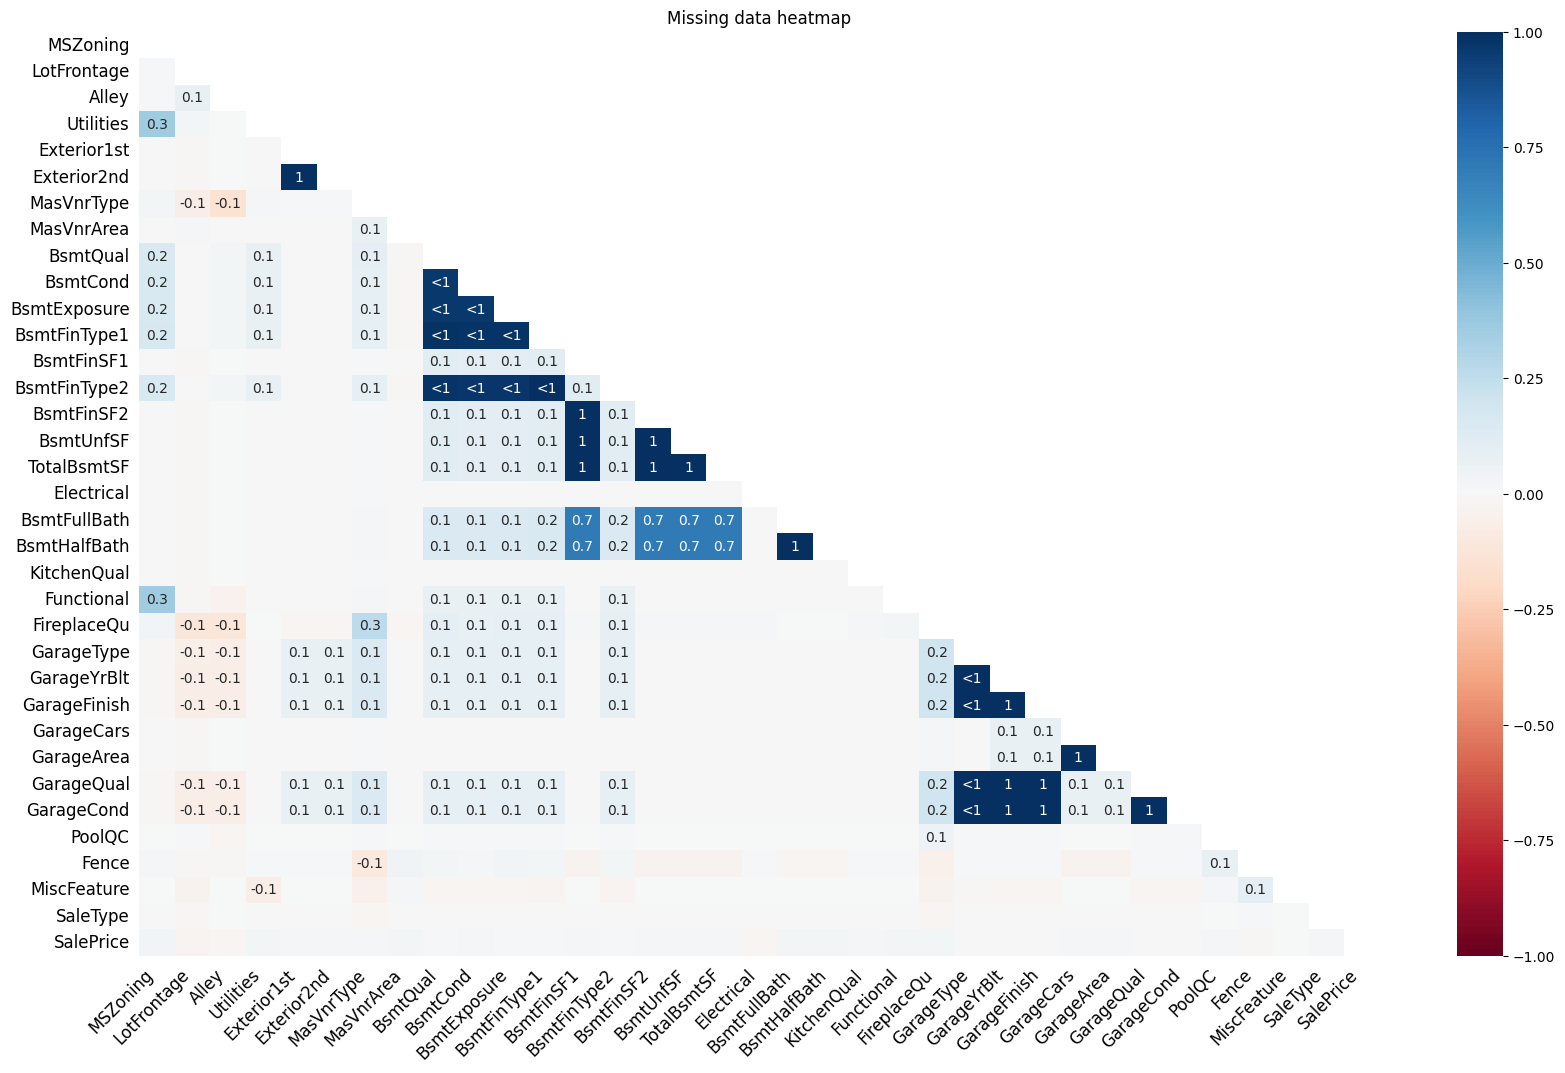

<Figure size 1200x600 with 0 Axes>

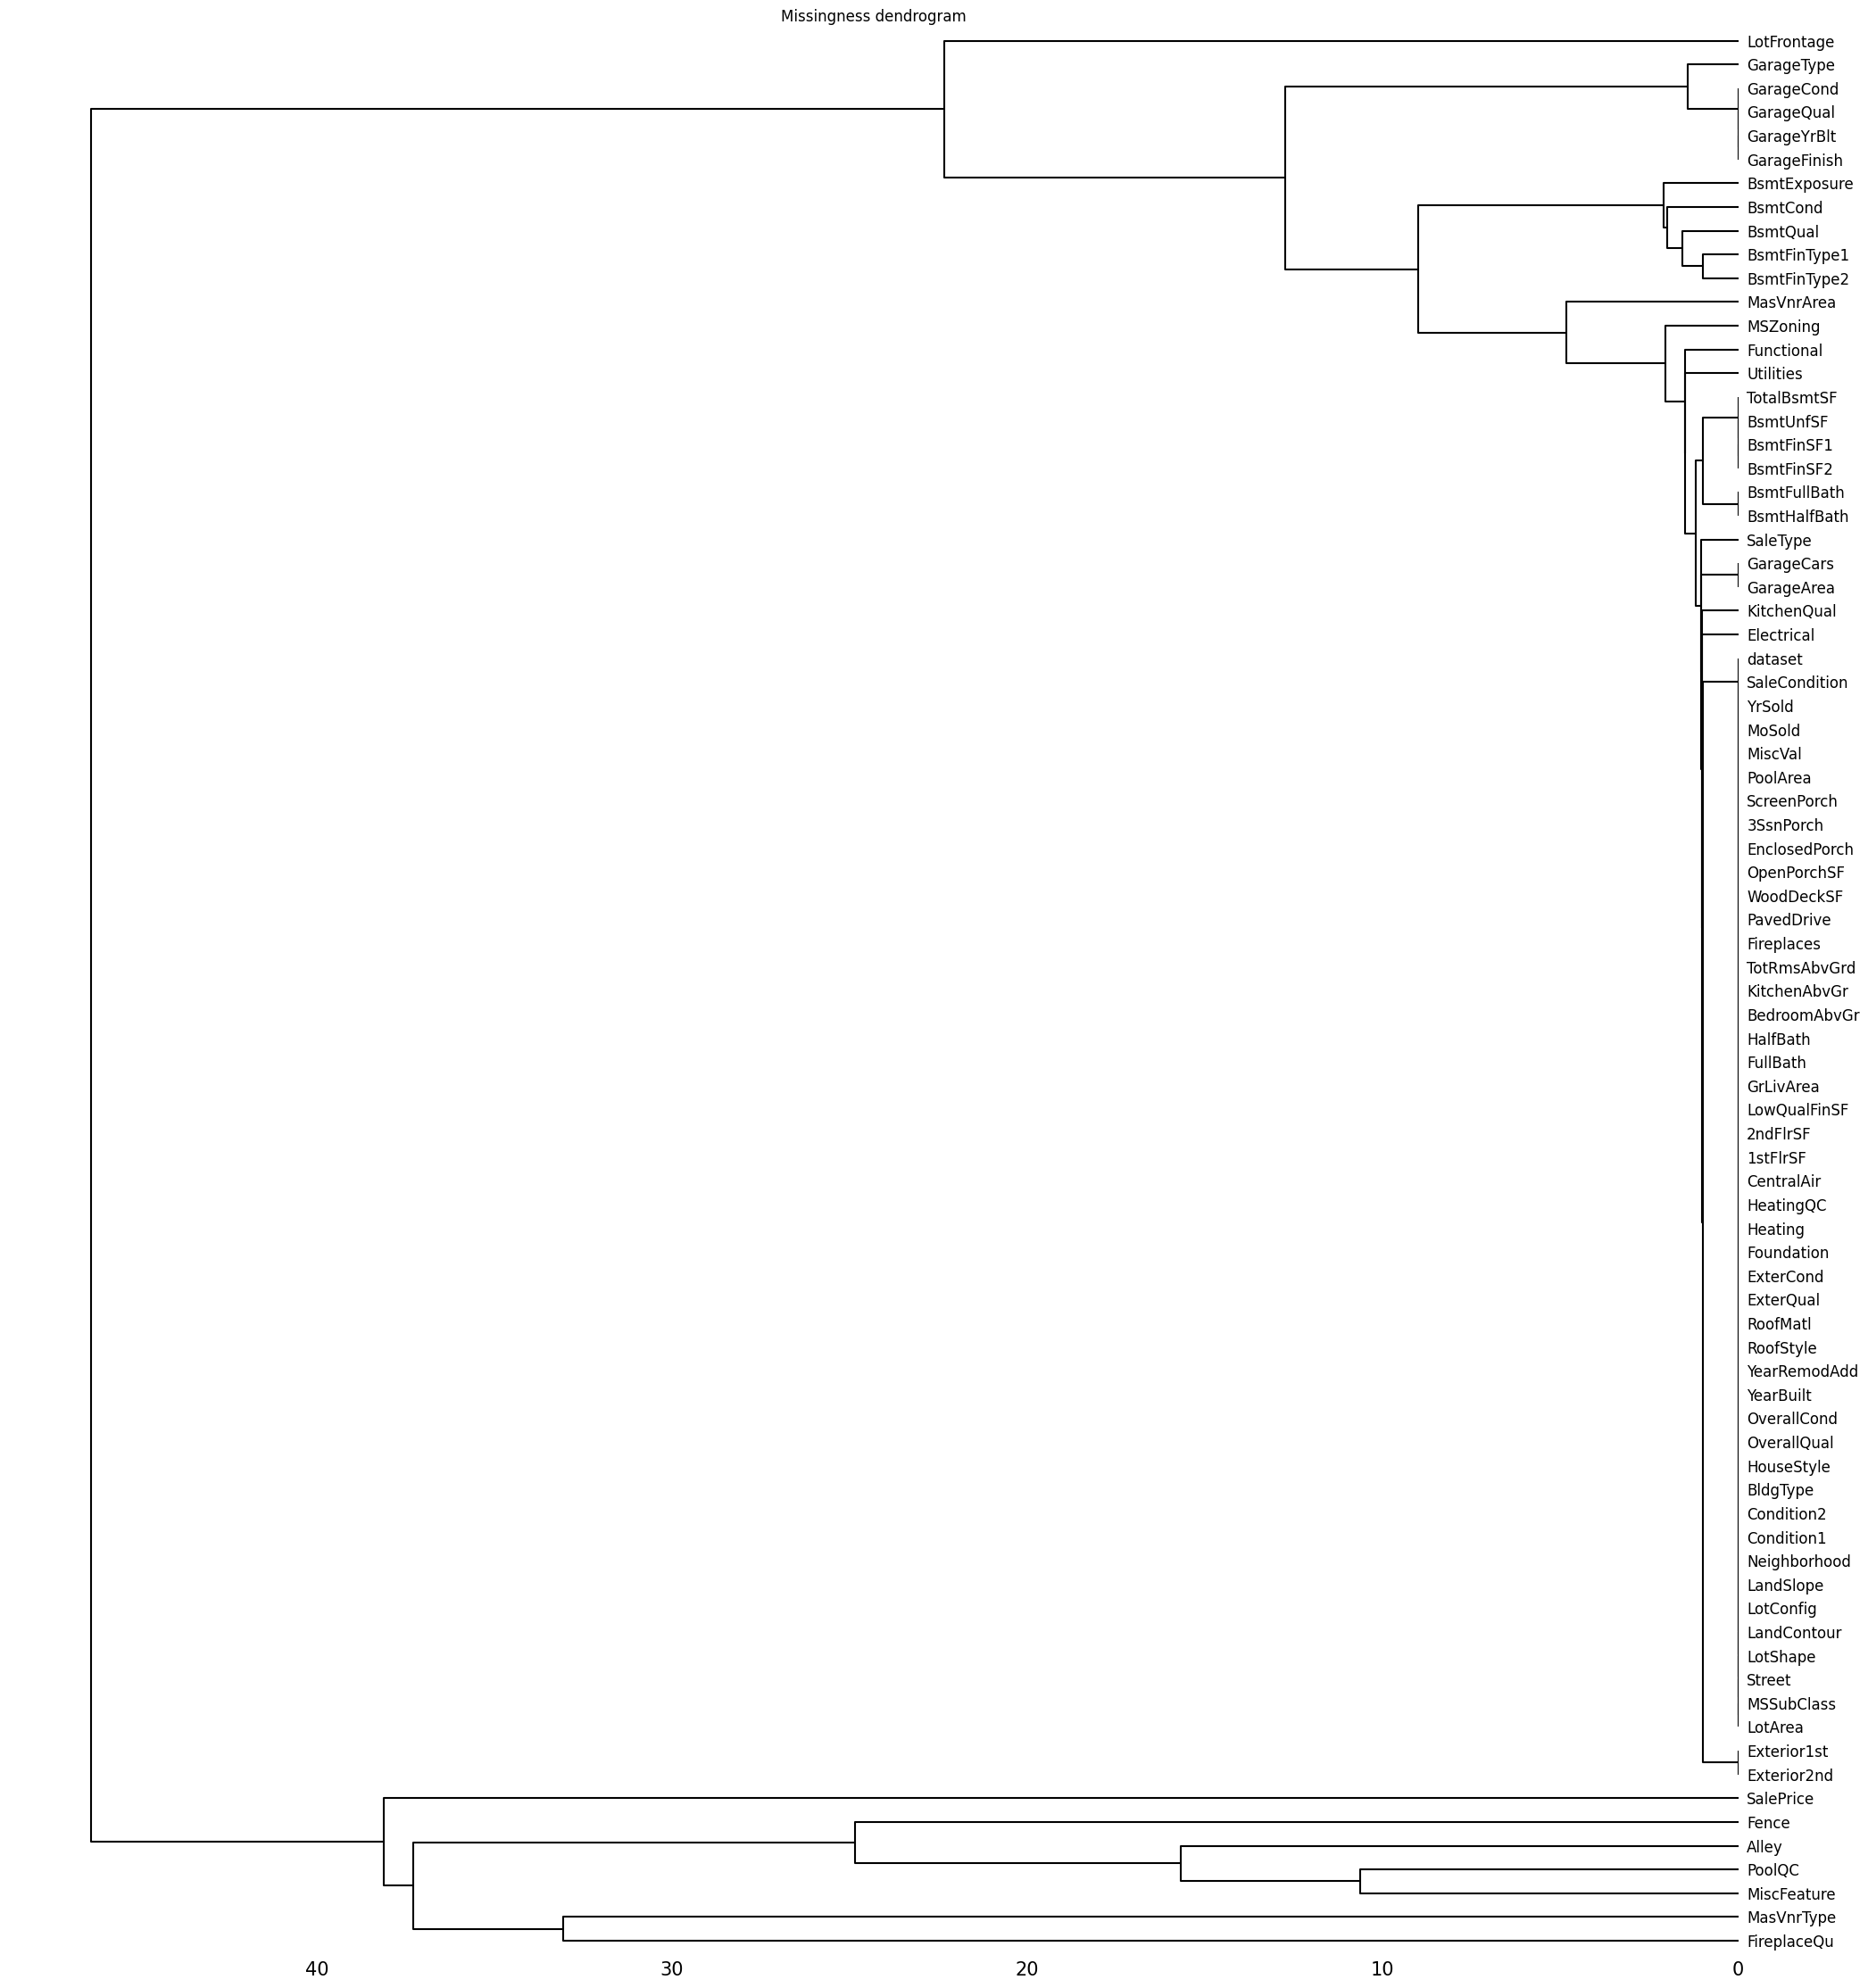

In [24]:
import missingno as msno

plt.figure(figsize=(12, 6))
msno.matrix(dataset_df, fontsize=12)
plt.title("Missing data matrix")
plt.show()

plt.figure(figsize=(12, 6))
msno.heatmap(dataset_df, fontsize=12)
plt.title("Missing data heatmap")
plt.show()

plt.figure(figsize=(12, 6))
msno.dendrogram(dataset_df, fontsize=12)
plt.title("Missingness dendrogram")
plt.show()

## Fill missing values with median

In [25]:
numeric_cols = dataset_df.select_dtypes(include=['float64', 'int64']).columns
median_values = dataset_df[numeric_cols].median()
dataset_df[numeric_cols] = dataset_df[numeric_cols].fillna(median_values)

print("Missing values after median imputation:")
print(dataset_df[numeric_cols].isna().sum().sort_values(ascending=False).head(20))

Missing values after median imputation:
MSSubClass      0
LotFrontage     0
LotArea         0
OverallQual     0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
MasVnrArea      0
BsmtFinSF1      0
BsmtFinSF2      0
BsmtUnfSF       0
TotalBsmtSF     0
1stFlrSF        0
2ndFlrSF        0
LowQualFinSF    0
GrLivArea       0
BsmtFullBath    0
BsmtHalfBath    0
FullBath        0
HalfBath        0
dtype: int64
